In [1]:
import argparse
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import math
import subprocess
import sys
import pandas as pd
import os
from itertools import chain

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Functions

## Koen's

In [2]:
uconv = {'nm': 1239.849, 'rcm': 8065.5, 'cm-1': 8065.5, 'ev': 1}
# colconv = {'nm': 3, 'rcm': 2, 'cm-1': 2, 'ev': 1}
fntsz = 10
lnsz = 0.8

def init(split_args):
    parser = argparse.ArgumentParser(formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument('folders', type=str, nargs='+',
                        help='Folders containing output files [and rate_vs_ead-file]')
    parser.add_argument('-e', '--ext', default='',type=str, help='extension for outputfiles (.out, .log, , ...)')
    parser.add_argument('-l', '--long', action='store_true', help='long output', default=False)
    parser.add_argument('-L', '--extralong', action='store_true', help='extra long output', default=False)
    parser.add_argument('-r', '--readable', action='store_true', help='readable output', default=False)

    parser.add_argument('-s', '--spec', action='store_true', help='Show spectra for abs, emi', default=False)
    parser.add_argument('-o', '--onefig', action='store_true', help='spec: add all graphs from a dir in 1 fig', default=False)
    parser.add_argument('-u', '--unit', type=str.lower, help='spec: choose eV, nm, rcm=cm-1', default='ev')
    parser.add_argument('-a', '--axis', type=float, nargs=2, help='spec: choose x-axis limits', default=None)

    parser.add_argument('-I', '--Icspec', action='store_true', help='Show spectra for IC, NR0', default=False)
    parser.add_argument('-O', '--Onefig', action='store_true', help='KicSpec: add all graphs from a dir in 1 fig', default=False)
    parser.add_argument('-U', '--Unit', type=str.lower, help='KicSpec: choose eV, nm, rcm=cm-1', default='ev')
    parser.add_argument('-P', '--Points', type=int, help='KicSpec: number of points for smoothing', default=10)
    parser.add_argument('-A', '--Axis', type=float, nargs=2, help='KicSpec: choose x-axis limits', default=None)
    args = parser.parse_args(split_args)

    if args.onefig:
        args.spec = True
    if args.Onefig:
        args.Icspec = True
    do_kicspec = {'spec':args.Icspec, 'unit':args.Unit, 'onefig':args.Onefig, 'points':args.Points, 'axis': args.Axis}
    do_spec = {'spec':args.spec, 'unit':args.unit, 'onefig':args.onefig, 'axis': args.axis}

    list_of_dicts = []
    for dirstr in args.folders:
        drg = Path(dirstr).expanduser().absolute()
        if not drg.is_dir():
            continue  # TODO: More checks!
        print(dirstr)
        outlst = getfl(drg, ext=args.ext)
        for outfl, outprop in outlst:
            datdic = inf_main(outfl, outprop, do_spec, do_kicspec)
            datdic['name'] = outfl.parent.relative_to(Path.cwd())
            list_of_dicts.append(datdic)
            # if plt.gca().get_legend_handles_labels() !=([],[]):
            if args.Icspec or args.spec:
                plt.legend()

    df = pd.DataFrame(list_of_dicts)
    df['Temp'] = df['Temp'].map('{:.0f}'.format)
    df['points'] = df['points'].map('{:.0f}'.format)
    df['tmax'] = df['tmax'].map('{:.0f}'.format)
    df['dt'] = df['dt'].map('{:.1f}'.format)
    df['Ead'] = df['Ead'].map('{:.2f}'.format)
    df['FWHM'] = df['FWHM'].map('{:.1e}'.format)
    df['brexp'] = df['brexp'].map('{:.1e}'.format)

    print('Ead in eV; FWHM in rcm')
    if args.readable:
        if args.long:
            prtstr = df[['name', 'rtsfsp', 'rt', 'Ead', 'Temp', 'BrType', 'FWHM']].to_string(index=False)
        elif args.extralong:
            prtstr = df[['name', 'rtsfsp', 'rt', 'Ead', 'Temp', 'BrType', 'FWHM', 'points', 'dt', 'tmax']].to_string(index=False)
        else:
            prtstr = df[['name', 'rtsfsp', 'Ead']].to_string(index=False)
        print(re.sub(r"([a-zA-Z0-9:/-]) ", r"\1, ", prtstr))  # re.MULTILINE stops replacing after 8 hits
    else:
        if args.long:
            print(df[['name', 'rtsfsp', 'rt', 'Ead', 'Temp', 'BrType', 'FWHM']].to_csv(index=False))
        elif args.extralong:
            print(df[['name', 'rtsfsp', 'rt', 'Ead', 'Temp', 'BrType', 'FWHM', 'points', 'dt', 'tmax']].to_csv(index=False))
        else:
            print(df[['name', 'rtsfsp', 'Ead']].to_csv(index=False))
    if args.Icspec or args.spec:
        plt.show()

def getfl(folder, ext=''):
    ''' 
    Creates a list with the paths for the fcc.out files. 
    'folder' argument should be given as 'path/to/file/'
    '''
    foutlst = []
    fldr_lst = list(Path(folder).expanduser().absolute().glob(f'./**/*{ext}'))
    for isfl in [f for f in fldr_lst if f.is_file()]:
        with open(isfl, 'rb',buffering=0) as fl:
            a = str(fl.read(2000))
            if re.search('FCCLASSES3', a):
                prop = re.search(r'PROPERTY += +([A-Z0-9]+)', a)
                if prop is not None:
                    foutlst.append((isfl, prop.group(1)))
                else:
                    print(f'Error, property not found: {isfl}', file=sys.stderr)
    return foutlst

def getinp(filepath):  # FWHM in a.u., Ead in eV
    script = ''
    infdic = {'Temp': math.nan, 'Ead': math.nan, 'tmax': math.nan, 'dt': math.nan, 'points': math.nan,
                'isgauss': '-', 'BrType': '-', 'FWHM': math.nan} #, 'Broadenfunc': '-'}
    script = """
                cat <<'END' | sh | xargs echo
                fl=%s
                grep -F "Temperature" $fl | awk '{print "Temp",$3}'
                grep -F -A1 "ADIABATIC ENERGY" $fl | tail -n1 | awk '{print "Ead", $1}' #Not converted to au anymore!
                # grep "Total time" $fl | awk '{print "tmax",41.341373*$4}'
                # grep "Time step" $fl | awk '{print "dt",41.341373*$5}'
                # grep "data points" $fl | awk '{print "points",$5}'
                grep -F "tfin  =" $fl | awk '{print "tmax",41.341373*$3}'
                grep -F "dt    =" $fl | awk '{print "dt",41.341373*$3}'
                grep -F "ntime =" $fl | awk '{print "points",$3}'
                grep -F "Broad. function" $fl | awk '{print "BrType",$4}'
                grep -E "HWHM {9}=" $fl | awk '{print "FWHM",2*0.0367485*$3}'
                grep -F "Broad. exponent" $fl | awk '{print "brexp", $4}'
END
                """ % filepath  # Total time, timestep etc not working with TI --> tfin, dt, ntime
        # TODO BROADFUN search for TI-case?
    p = subprocess.Popen(script, stdout=subprocess.PIPE, shell=True, executable='/bin/bash')
    inflist = p.stdout.readline().decode('utf8').split()
    for i in range(len(inflist) // 2):
        try:
            infdic[inflist[2 * i]] = float(inflist[2 * i + 1])
        except ValueError:
            infdic[inflist[2 * i]] = inflist[2 * i + 1]
    return infdic

def rates(filepath, prop):
    search_dic = {'EMI': 'kr(s-1) =',
                  'IC': 'IC rate constant (s-1)',
                  'NR0': 'rate constant (s-1)'}
    if prop not in search_dic:
        return 0
    # watch out for r-string (no escape needed) and -E flag
    script = fr"tail -n100 {filepath} | grep '{search_dic[prop]}' | sed -E 's/^.* ([-]?[0-9]+[.]?[0-9]*E?[0-9-]*)/\1/'"
    p = subprocess.Popen(script, stdout=subprocess.PIPE, shell=True, executable='/bin/bash').stdout
    try:
        return float(p.readline().decode('utf8'))
    except ValueError:
        return None

def times(filepath):
    script = "tail %s | grep 'CPU (s)   ' | awk '{print $3}'" % filepath
    # Speeding up with tail! # no use of f-string, due to {}'s
    p = subprocess.Popen(script, stdout=subprocess.PIPE, shell=True, executable='/bin/bash').stdout
    return float(p.readline().decode('utf8'))

def rts_from_spec(datfile, ead, points=10, spec=True, unit='ev', onefig=False, axis=None):  # todo: how to choose points?; #todo: Show graph?; .......
    label = str(datfile.parent.relative_to(Path.cwd()))
    fomat = np.genfromtxt(datfile)
    y_smo = smooth(fomat[:, 1], points)
    # fo_smo = fomat[:, 1]
    xval = closest(fomat[:, 0], ead)
    yval = y_smo[list(fomat[:, 0]).index(xval)]
    try:
        ytestval = y_smo[list(fomat[:, 0]).index(xval) + 1]
    except IndexError:
        print(f'{label}      ,kic-val on edge of plotted region? index =, {list(fomat[:, 0]).index(xval)}, {len(y_smo)}')
        ytestval = y_smo[list(fomat[:, 0]).index(xval) - 1]
    smoothmessage = f'{label}      , SmoothingNotComplete!, {yval:0.2e}, {ytestval:0.2e}'
    try:
        if math.log10(ytestval) - math.log10(yval) > 0.05:
            print(smoothmessage)
    except ValueError:
        print(smoothmessage)

    if spec:
        xvals, yvals = fomat[:,0]*uconv[unit], fomat[:,1]
        yvals = np.array([math.log10(abs(max(1, i))) for i in yvals])
        y_smo = np.array([math.log10(abs(max(1, i))) for i in y_smo])
        if onefig:
            fig = plt.figure('knr/kic', figsize=[4,3])
            plt.plot(xvals, y_smo, linewidth=lnsz, alpha=0.5, color='r')  # smooth
            plt.plot(xvals, yvals, linewidth=lnsz, alpha=0.8, label=label)  # kic
        else:
            fig = plt.figure(label, figsize=[4,3])
            # returns log(kic), except if kic is < 1 (negative), then 0
            plt.plot(xvals, yvals, linewidth=lnsz, alpha=0.8, color='k')  # kic
            plt.plot(xvals, y_smo, linewidth=lnsz, alpha=0.5, color='r')  # smooth
        if axis is not None:
            plt.xlim([axis[0], axis[1]])
        plt.plot(ead, math.log10(abs(max(1, yval))), 'X', color='k')
        fig.tight_layout()
    return yval

def genspec(specfile, unit='ev', axis=None, onefig=False):
    label = str(specfile.parent.relative_to(Path.cwd()))
    if onefig:
        plt.figure('Abs-Emi', figsize=(4, 3))
    else:
        plt.figure(label, figsize=(4, 3))
    specmat = np.genfromtxt(specfile, delimiter="")
    specmat[:, 1] *= 1 / max(specmat[:, 1])
    k = uconv[unit]
    if unit == 'nm':
        specmat[:, 0] = np.reciprocal(specmat[:, 0], where=specmat[:, 0] != 0)
        if axis is None:
            plt.axis([250, 950, 0, 1])
    if axis is not None:
        plt.axis([axis[0], axis[1], 0, 1])
    specmat[:, 0] *= k
    # if onefig:
    plt.plot(specmat[:, 0], specmat[:, 1], linewidth=lnsz, alpha=0.8, label=label)
    plt.xlabel(unit, fontsize=fntsz)
    # plt.ylabel('Intensity', fontsize=fntsz)
    plt.tight_layout()
    # plt.savefig('/home/koen/un2/mmp/tmp.png')
    return specmat[:, 0], specmat[:, 1]

def inf_main(flname, prop, specargs, kicspecargs):  # FWHM in rcm, Ead in eV
    datdic = getinp(flname)
    if prop in ['EMI', 'IC', 'NR0']:
        rt = rates(flname, prop)
        if rt is None:
            rt = '    ---'
            print(f'Error: No rates in file? {flname.relative_to(Path.cwd())}')
        else:
            rt = f'{rt:.2e}'
    else:
        rt = '       /'
    datdic['rt'] = rt
    datdic['rtsfsp'] = '      /'
    if prop in ['IC', 'NR0']:
        plotfile = [y for y in flname.parent.glob('k??_vs_Ead_T?.dat')]
        if plotfile != []:
            if len(plotfile) > 1:
                print(f'Warning: more than one k??_vs_Ead_T?.dat-file found!, using: {plotfile[0]}')
            datdic['rtsfsp'] = f'{rts_from_spec(plotfile[0], datdic["Ead"], **kicspecargs):.2e}'
    elif prop in ['OPA', 'EMI'] and specargs['spec']:
        plotfile = [y for y in flname.parent.glob('spec_Int_T?.dat')]
        if plotfile != []:
            if len(plotfile) > 1:
                print(f'Warning: more than one spec_Int_T?.dat-file found!, using: {plotfile[0]}')
            r = dict(specargs)
            del r['spec']
            genspec(plotfile[0], **r)

    if datdic['isgauss'] == '.f.':
        datdic['BrType'], datdic['FWHM'], datdic['Broadenfunc'] = '-', math.nan, math.nan
    if re.search('LOR', datdic['BrType']):  # more exact fwhm
        datdic['FWHM'] = datdic['brexp'] * 2 * 219474
    elif re.search('GAU', datdic['BrType']):
        datdic['FWHM'] = 2 * 219474 * math.sqrt(
            2 * datdic['brexp'] / (math.sqrt(2 * math.log10(2))))  # todo: test this expression
    return datdic

def mmpdir_construct(gmap):
    # Starts digging in the folder and stops at layer before kr/ --> saves only last layer in grmaps
    # and subtracts gmap from the mapnames
    maplist = [gmap + i for i in next(os.walk(gmap))[1]]
    m = 0
    while 'kr' not in list(chain(*[os.listdir(i) for i in maplist])):
        m = len(maplist)
        for innermap in maplist:
            dirs = next(os.walk(innermap))[1]
            if 'kr' in dirs or 'kic' in dirs:
                break
            for i in dirs:
                maplist.append(innermap + '/' + i)
    grmaps = [i.replace(gmap, '') for i in maplist[m:]]
    grmaps = [x+'/' for x in grmaps if 'kr' in os.listdir(gmap+x)]
    grmaps.sort()
    return grmaps

def smooth(y, box_pts):
    box = np.ones(box_pts) / box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

def closest(lst, k):
    return lst[min(range(len(lst)), key=lambda i: abs(lst[i] - k))]

def tail(f, n):
    proc = subprocess.Popen(['tail', '-n', str(n), f], stdout=subprocess.PIPE)
    t = [i.decode('utf8').split() for i in proc.stdout.readlines()][0]
    return t

def is_int(n):
    try:
        float(n)
    except ValueError:
        return False
    else:
        return float(n).is_integer()


In [3]:
# How to use Koen's script as is in VSCode.
# split_args = ['/home/mariana/indigo-carmine/indigo/rates/ah/em-td-fc/dienol-4opt-w-em-ahc-0.05', '-L', '-o']
# init(split_args)

## Adapted

In [4]:
def data_spec(specfile, unit='ev', axis=None, onefig=False):
    ''' Returns energies and intensities values from spectrum.
        Inspired in Koen's scripts '''

    uconv = {'nm': 1239.849, 'rcm': 8065.5, 'cm-1': 8065.5, 'ev': 1}
    specmat = np.genfromtxt(specfile, delimiter="")
    specmat[:, 1] *= 1 / max(specmat[:, 1])
    k = uconv[unit]
    if unit == 'nm':
        specmat[:, 0] = np.reciprocal(specmat[:, 0], where=specmat[:, 0] != 0)
    specmat[:, 0] *= k
    
    return specmat[:, 0], specmat[:, 1]

def path_spec(folder, prop='em', ext='dat'):
    ''' 
    Creates a list with the paths for the *.dat files. 
    'folder' argument should be given as 'path/to/file/'
    Inspired in Koen's scripts.
    '''
    if prop == 'em':
        fldr_lst = list(Path(folder).expanduser().absolute().glob(f'./**/*spec_LS_T?.dat'))
    elif prop == 'ic':
        fldr_lst = list(Path(folder).expanduser().absolute().glob(f'./**/*k??_vs_Ead_T?.dat'))
    return fldr_lst

def data_table(path, unit):
    ''' Collects all the data from the .dat files in path and
        stores it in a dataframe.
    '''
    df = pd.DataFrame()
    for item in path : 
        # print(item)
        x_name = str(item).split(sep='/')[-3]+'-'+str(item).split(sep='/')[-2]+'_x'
        y_name = str(item).split(sep='/')[-3]+'-'+str(item).split(sep='/')[-2]+'_y'
        x, y = data_spec(item, unit)
        
        temp_df = pd.DataFrame({x_name: x,  y_name: y})
        df = pd.concat([df, temp_df], axis=1)
    
    return df   

def plot_together(df_molecule, labels, systems, size=(5,5), save=False, name=None, type_plot='line', unit='ev', num_rows='None', num_cols=None):
    ''' Plot things together (in the same plot and as subplots). 
    '''
    if num_rows and num_cols == None: 
        num_cols = math.ceil(math.sqrt(len(systems)))
        num_rows = math.ceil(len(systems) / num_cols)

    # fig, axs = plt.subplots(num_rows, num_cols, figsize=size)
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(size[0] * num_cols,size[1] * num_rows),
                             gridspec_kw={'width_ratios': [1]*num_cols, 'height_ratios': [1]*num_rows})
    
    colors=["#d35b17", "#546a7b","#0D2C54", "#a92216", "#8FA53A",   "#EF6F6C", "#FFB400", "#F6511D", "#0a9588", "#465775", "#d35b17" ]
    # axis = 0

    df = df_molecule.astype(float)

    for j, system in enumerate(systems):
        for i, item in enumerate(labels):

            x_column = system+str(item)+'_x'
            y_column = system+str(item)+'_y'

            data = pd.DataFrame()
            data['x'] = df[x_column]
            data['y'] = df[y_column]
            
            row = j // len(axs[0])
            col = j % len(axs[0])            
            
            if unit == 'nm':
                data = data.sort_values(by='x', ascending=False)
                axs[row , col].set_xlim(left=800, right=400)
                axs[row , col].set_xlabel('energy / nm')

            else: 
                # axs[row , col].set_xlim(left=0, right=400)
                axs[row , col].set_ylim(bottom=0)
                axs[row , col].set_xlabel('energy / eV')                

            if type_plot == '.':
                axs[row , col].plot(data['x'], data['y'], linestyle='-', linewidth=2, marker='.',  markersize=5 , label=labels[i], c=colors[i]) 
            elif type_plot == 'line':
                axs[row , col].plot(data['x'], data['y'], linestyle='-', linewidth=2, label=labels[i], c=colors[i]) 
            
            elif type_plot == 'scatter':
                axs[row , col].scatter(data['x'], data['y'], s=7,  label=labels[i], c=colors[i]) 



            axs[row , col].grid(True)
            axs[row , col].set_ylabel(' Intensity ')
            axs[row , col].legend()
            axs[row , col].set_title(system)
            plt.subplots_adjust(wspace=0.25, hspace=0.25)
        # axis+=1
    plt.show()
    
    if save == True:
        plt.savefig(name, dpi=300, format='.png', bbox_inches='tight', transparent=True)
        
def plot_sep(df_molecule, systems, size=(5,5), save=False, name=None, type_plot='line', unit='ev', labels=None):
    ''' Plot things separately. 
    '''
    
    num_cols = 1
    num_rows = 1
    
    fig, axs = plt.subplots(figsize=(size[0] * num_cols,size[1] * num_rows),
                             gridspec_kw={'width_ratios': [1]*num_cols, 'height_ratios': [1]*num_rows})
    
    colors=["#d35b17", "#546a7b","#0D2C54", "#a92216", "#8FA53A",   "#EF6F6C", "#FFB400", "#F6511D", "#0a9588", "#465775", "#d35b17" ]

    df = df_molecule.astype(float)

    for j, system in enumerate(systems):

            x_column = system+'_x'
            y_column = system+'_y'

            data = pd.DataFrame()
            data['x'] = df[x_column]
            data['y'] = df[y_column]
            
            if unit == 'nm':
                data = data.sort_values(by='x', ascending=False)
                axs.set_xlim(left=800, right=400)
                axs.set_xlabel('energy / nm')

            else: 
                axs.set_xlabel('energy / eV')                

            if labels == None:
                labels == system
                
            if type_plot == '.':
                axs.plot(data['x'], data['y'], linestyle='-', linewidth=2, marker='.',  markersize=5 , label=labels[j], c=colors[j]) 
            elif type_plot == 'line':
                axs.plot(data['x'], data['y'], linestyle='-', linewidth=2, label=labels[j], c=colors[j]) 
            
            elif type_plot == 'scatter':
                axs.scatter(data['x'], data['y'], s=7,  label=labels[j], c=colors[j]) 

            axs.grid(True)
            axs.set_ylabel(' Intensity ')
            axs.legend()
            axs.set_title(name)
            plt.subplots_adjust(wspace=0.25, hspace=0.25)
    plt.show()
    
    if save == True:
        plt.savefig(name, dpi=300, format='.png', bbox_inches='tight', transparent=True)

# Results

In [5]:
### ADIABATIC HESSIAN 
### EMISSION

path_em_fc = path_spec('ah/')
# path_em_ht = path_spec('ah/')
path_ic_fc = path_spec('ah/', prop='ic')

path_enol_td   = [item for item in path_em_fc + path_ic_fc  if '/enol'      and 'td' in str(item)]
path_keto_td   = [item for item in path_em_fc               if '/keto'      and 'td' in str(item)]

path_enol_ti   = [item for item in path_em_fc + path_ic_fc  if '/enol'      and 'ti' in str(item)]
path_keto_ti   = [item for item in path_em_fc               if '/keto'      and 'ti' in str(item)]

[PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/keto-1opt-w-ic-ahc-0.02/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/dienol-1opt-w-ic-ahc-0.5/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/keto-1opt-w-ic-ahi-0.001/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/keto-1opt-w-ic-ahi-0.002/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/enol-1opt-w-ic-ahi-0.2/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/enol-1opt-w-ic-ahi-0.5/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/keto-1opt-w-ic-ahi-0.003/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah/ic-td-fc/keto-1opt-w-ic-ahi-0.02/kic_vs_Ead_TD.dat'),
 PosixPath('/home/mariana/dirac/indigo-carmine/indigo/rates/ah

In [6]:
# [item for item in path_dienol if 'TI' in str(item)]

In [8]:
### ADIABATIC HESSIAN
### IC

path_ic_fc = path_spec('ah/ic-td-fc/', prop='ic')

path_ic_dienol = [item for item in path_ic_fc  if '/dienol' in str(item)]
path_ic_enol   = [item for item in path_ic_fc  if '/enol'   in str(item)]
path_ic_keto   = [item for item in path_ic_fc  if '/keto'   in str(item)]

## Dienol

In [10]:
path_dienol_td = [item for item in path_em_fc + path_ic_fc  if '/dienol'    and 'td' in str(item)]
path_dienol_ti = [item for item in path_em_fc + path_ic_fc  if '/dienol'    and 'ti' in str(item)]

In [11]:
df_dienol_td = data_table(path_dienol_td, unit='ev')

In [12]:
df_dienol_td.head()

,em-td-fc-enol-4opt-w-em-ahc-0.002_x,em-td-fc-enol-4opt-w-em-ahc-0.002_y,em-td-fc-enol-4opt-w-em-ahc-0.003_x,em-td-fc-enol-4opt-w-em-ahc-0.003_y,em-td-fc-keto-1opt-w-em-ahi-0.003_x,em-td-fc-keto-1opt-w-em-ahi-0.003_y,em-td-fc-dienol-4opt-w-em-ahi-0.002_x,em-td-fc-dienol-4opt-w-em-ahi-0.002_y,em-td-fc-keto-6opt-w-em-ahc-0.05_x,em-td-fc-keto-6opt-w-em-ahc-0.05_y,...,ic-td-fc-dienol-1opt-w-ic-ahi-0.5_x,ic-td-fc-dienol-1opt-w-ic-ahi-0.5_y,ic-td-fc-dienol-1opt-w-ic-ahi-0.003_x,ic-td-fc-dienol-1opt-w-ic-ahi-0.003_y,ic-td-fc-dienol-4opt-w-ic-ahi-0.001_x,ic-td-fc-dienol-4opt-w-ic-ahi-0.001_y,ic-td-fc-keto-1opt-w-ic-ahi-0.2_x,ic-td-fc-keto-1opt-w-ic-ahi-0.2_y,ic-td-fc-dienol-4opt-w-ic-ahi-0.05_x,ic-td-fc-dienol-4opt-w-ic-ahi-0.05_y
0,0.0690,1.108489e-11,0.0690,1.118028e-11,0.0000,6.937299e-08,0.0000,2.908209e-08,0.37454,2.652142e-11,...,-0.45,0.126341,-0.4614,1.016589e-08,-0.4503,5.016554e-12,-0.42,0.002698,-0.450,1.875771e-10
1,0.0692,1.113893e-11,0.0693,1.121526e-11,0.0003,6.963112e-08,0.0002,2.913145e-08,0.37954,2.796189e-11,...,-0.40,0.155512,-0.4611,1.031806e-08,-0.4502,5.027121e-12,-0.40,0.003722,-0.445,2.379156e-10
2,0.0694,1.117604e-11,0.0696,1.126281e-11,0.0006,6.989177e-08,0.0004,2.918091e-08,0.38454,2.943973e-11,...,-0.35,0.189307,-0.4608,1.047232e-08,-0.4501,5.043817e-12,-0.38,0.005086,-0.440,2.993542e-10
3,0.0696,1.116527e-11,0.0699,1.131001e-11,0.0009,7.015479e-08,0.0006,2.923045e-08,0.38954,3.096413e-11,...,-0.30,0.227910,-0.4605,1.062882e-08,-0.4500,5.190549e-12,-0.36,0.006881,-0.435,3.742230e-10
4,0.0698,1.121477e-11,0.0702,1.134149e-11,0.0012,7.042006e-08,0.0008,2.928008e-08,0.39454,3.254258e-11,...,-0.25,0.271375,-0.4602,1.078712e-08,-0.4499,5.128695e-12,-0.34,0.009222,-0.430,4.652974e-10


In [10]:
# [item for item in path_dienol_ti + path_ic_fc  if '/home/mariana/indigo-carmine/indigo/rates/ah/em-ti-ht/enol-4opt-w-em-ahc-0.003/spec_LS_TI.dat' in str(item)] 

In [11]:
df_dienol_ti = data_table(path_dienol_ti, unit='ev')

### Broadening

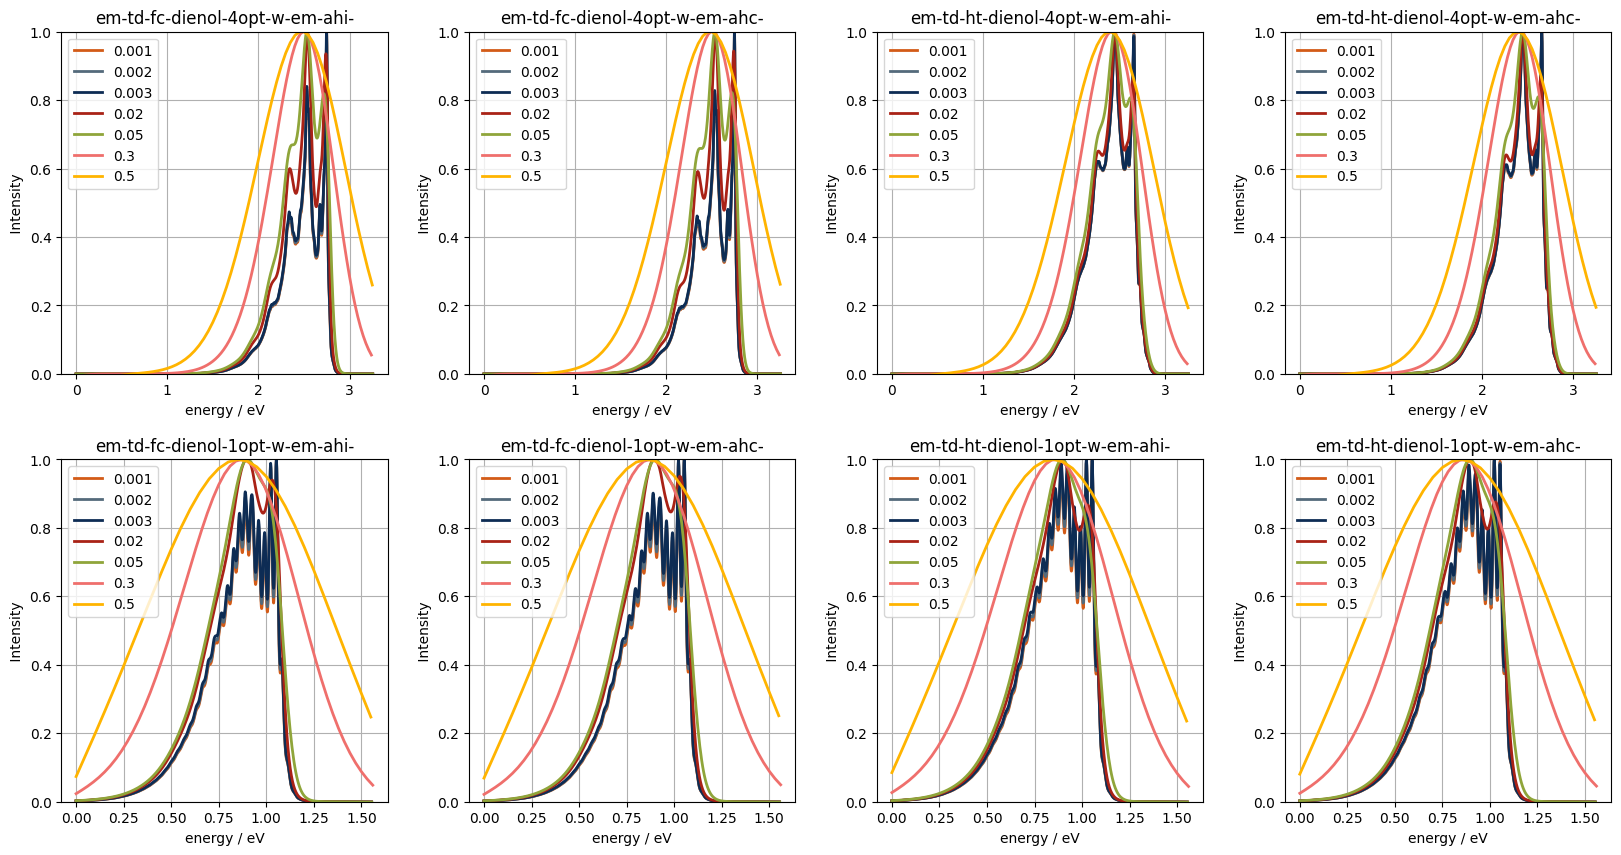

In [12]:
broadening = [0.001, 0.002, 0.003, 0.02, 0.05, 0.3, 0.5]
systems=['em-td-fc-dienol-4opt-w-em-ahi-', 'em-td-fc-dienol-4opt-w-em-ahc-', 'em-td-ht-dienol-4opt-w-em-ahi-', 'em-td-ht-dienol-4opt-w-em-ahc-', 
         'em-td-fc-dienol-1opt-w-em-ahi-', 'em-td-fc-dienol-1opt-w-em-ahc-', 'em-td-ht-dienol-1opt-w-em-ahi-', 'em-td-ht-dienol-1opt-w-em-ahc-']
plot_together(df_dienol_td, broadening, systems, unit='ev', num_cols=4, num_rows=2)

In [13]:
df_dienol_ti.columns

Index(['em-ti-ht-enol-4opt-w-em-ahc-0.003_x',
       'em-ti-ht-enol-4opt-w-em-ahc-0.003_y',
       'em-ti-ht-keto-1opt-w-em-ahi-0.003_x',
       'em-ti-ht-keto-1opt-w-em-ahi-0.003_y',
       'em-ti-ht-dienol-4opt-w-em-ahi-0.002_x',
       'em-ti-ht-dienol-4opt-w-em-ahi-0.002_y',
       'em-ti-ht-keto-6opt-w-em-ahc-0.05_x',
       'em-ti-ht-keto-6opt-w-em-ahc-0.05_y',
       'em-ti-ht-enol-4opt-w-em-ahc-0.1_x',
       'em-ti-ht-enol-4opt-w-em-ahc-0.1_y',
       ...
       'em-ti-fc-enol-1opt-w-em-ahc-0.1_x',
       'em-ti-fc-enol-1opt-w-em-ahc-0.1_y',
       'em-ti-fc-dienol-1opt-w-em-ahc-0.5_x',
       'em-ti-fc-dienol-1opt-w-em-ahc-0.5_y',
       'em-ti-fc-enol-1opt-w-em-ahi-0.001_x',
       'em-ti-fc-enol-1opt-w-em-ahi-0.001_y',
       'em-ti-fc-enol-4opt-w-em-ahi-0.05_x',
       'em-ti-fc-enol-4opt-w-em-ahi-0.05_y',
       'em-ti-fc-dienol-4opt-w-em-ahc-0.1_x',
       'em-ti-fc-dienol-4opt-w-em-ahc-0.1_y'],
      dtype='object', length=428)

KeyError: 'em-ti-fc-dienol-4opt-w-em-ahc-0.001_x'

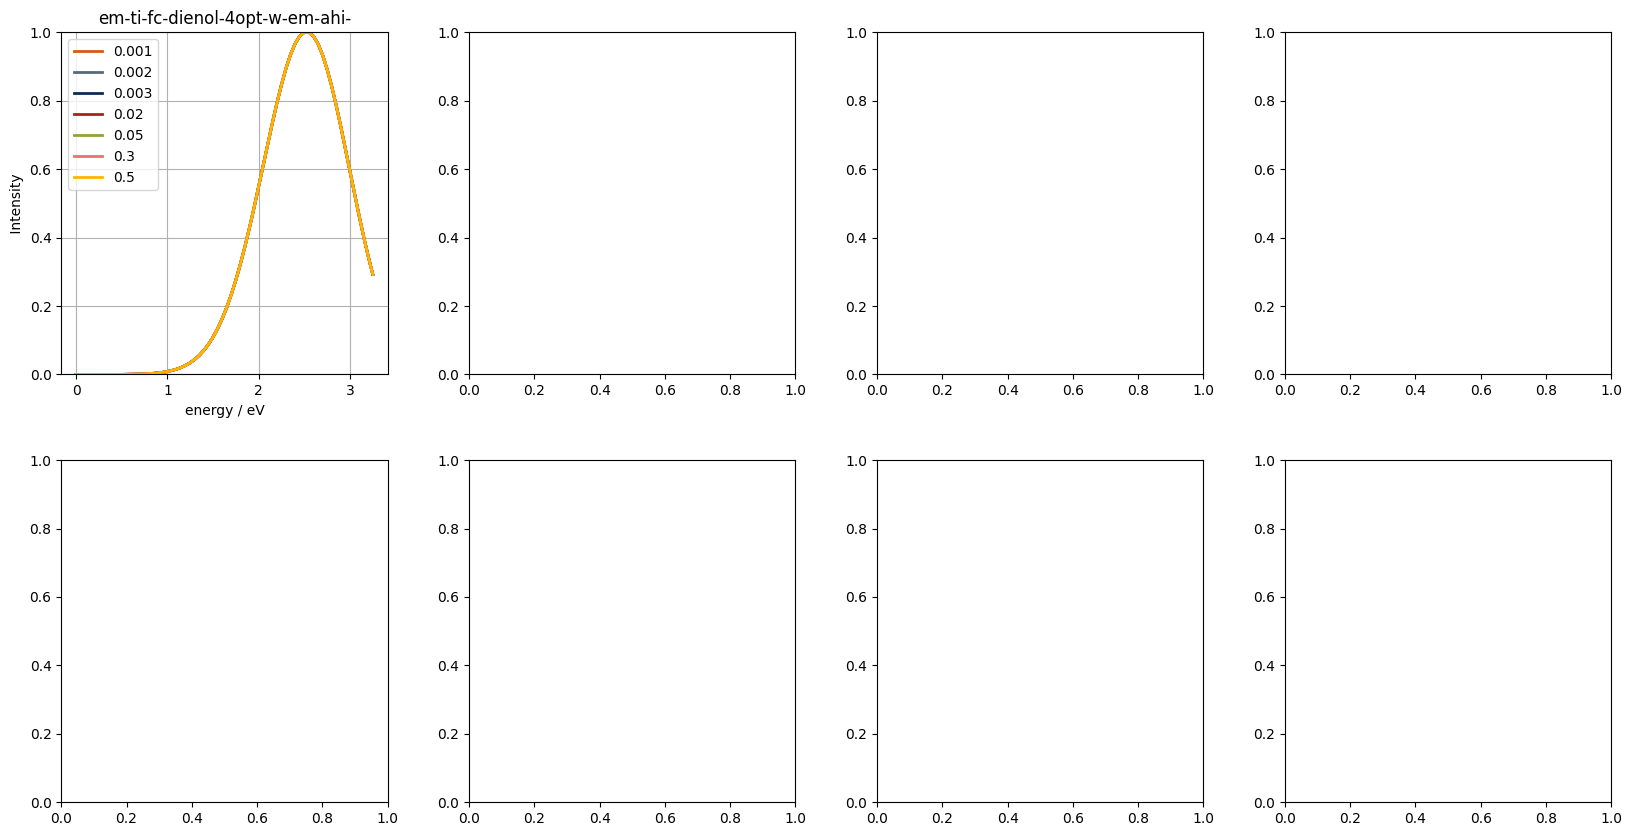

In [14]:
broadening = [0.001, 0.002, 0.003, 0.02, 0.05, 0.3, 0.5]
systems=['em-ti-fc-dienol-4opt-w-em-ahi-', 'em-ti-fc-dienol-4opt-w-em-ahc-', 'em-ti-ht-dienol-4opt-w-em-ahi-', 'em-ti-ht-dienol-4opt-w-em-ahc-', 
         'em-ti-fc-dienol-1opt-w-em-ahi-', 'em-ti-fc-dienol-1opt-w-em-ahc-', 'em-ti-ht-dienol-1opt-w-em-ahi-', 'em-ti-ht-dienol-1opt-w-em-ahc-']
plot_together(df_dienol_ti, broadening, systems, unit='ev', num_cols=4, num_rows=2)

### Parameters

In [115]:
systems=['em-td-fc-dienol-4opt-w-em-ahi-0.05', 'em-td-fc-dienol-4opt-w-em-ahc-0.05', 'em-td-ht-dienol-4opt-w-em-ahi-0.05', 
         'em-td-ht-dienol-4opt-w-em-ahc-0.05', 'em-td-fc-dienol-1opt-w-em-ahi-0.05', 'em-td-fc-dienol-1opt-w-em-ahc-0.05', 
         'em-td-ht-dienol-1opt-w-em-ahi-0.05', 'em-td-ht-dienol-1opt-w-em-ahc-0.05']

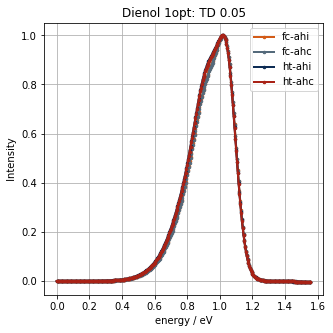

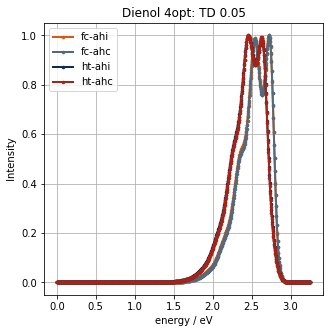

In [116]:
plt_dienol4opt=['em-td-fc-dienol-4opt-w-em-ahi-0.05', 'em-td-fc-dienol-4opt-w-em-ahc-0.05', 'em-td-ht-dienol-4opt-w-em-ahi-0.05', 
         'em-td-ht-dienol-4opt-w-em-ahc-0.05']
plt_dienol1opt=['em-td-fc-dienol-1opt-w-em-ahi-0.05', 'em-td-fc-dienol-1opt-w-em-ahc-0.05', 
         'em-td-ht-dienol-1opt-w-em-ahi-0.05', 'em-td-ht-dienol-1opt-w-em-ahc-0.05']

plot_sep(df_dienol_td, plt_dienol1opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Dienol 1opt: TD 0.05')

plot_sep(df_dienol_td, plt_dienol4opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Dienol 4opt: TD 0.05')

### IC

KeyError: 'ic-td-fc-dienol-1opt-w-ic-ahi-0.001_x'

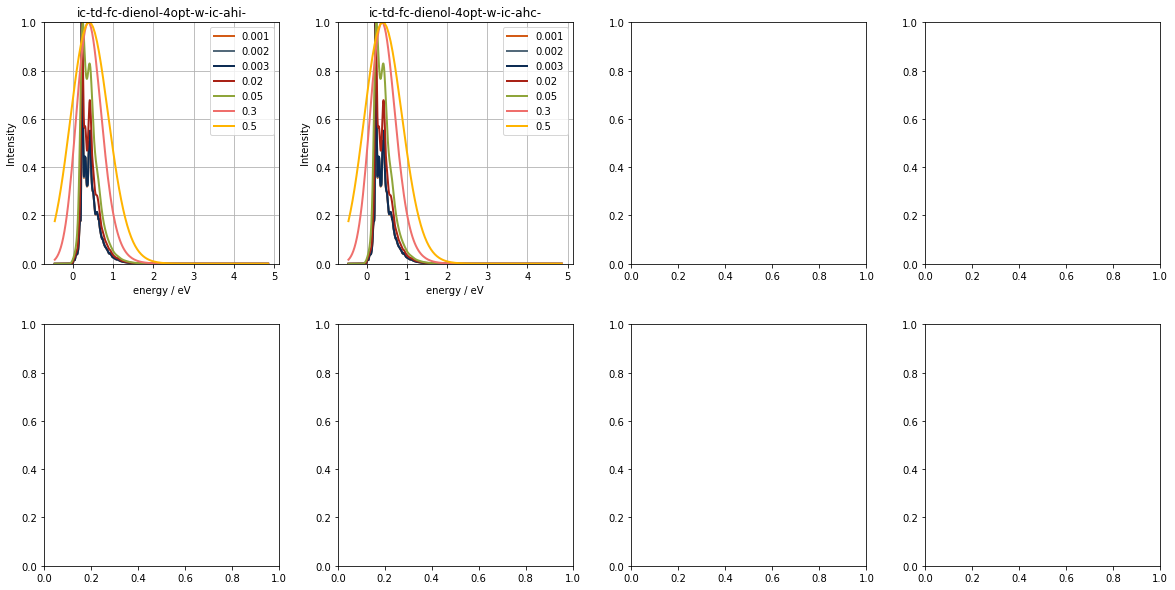

In [14]:
broadening = [0.001, 0.002, 0.003, 0.02, 0.05, 0.3, 0.5]
# systems=['ic-td-fc-dienol-4opt-w-ic-ahi-', 'ic-td-fc-dienol-4opt-w-ic-ahc-', 'ic-td-ht-dienol-4opt-w-ic-ahi-', 'ic-td-ht-dienol-4opt-w-ic-ahc-', 
#          'ic-td-fc-dienol-1opt-w-ic-ahi-', 'ic-td-fc-dienol-1opt-w-ic-ahc-', 'ic-td-ht-dienol-1opt-w-ic-ahi-', 'ic-td-ht-dienol-1opt-w-em-ahc-']

systems=['ic-td-fc-dienol-4opt-w-ic-ahi-', 'ic-td-fc-dienol-4opt-w-ic-ahc-', 
         'ic-td-fc-dienol-1opt-w-ic-ahi-', 'ic-td-fc-dienol-1opt-w-ic-ahc-']

plot_together(df_dienol_td, broadening, systems, unit='ev', num_cols=4, num_rows=2)

## Enol

In [128]:
df_enol_td   = data_table(path_enol_td, unit='ev')

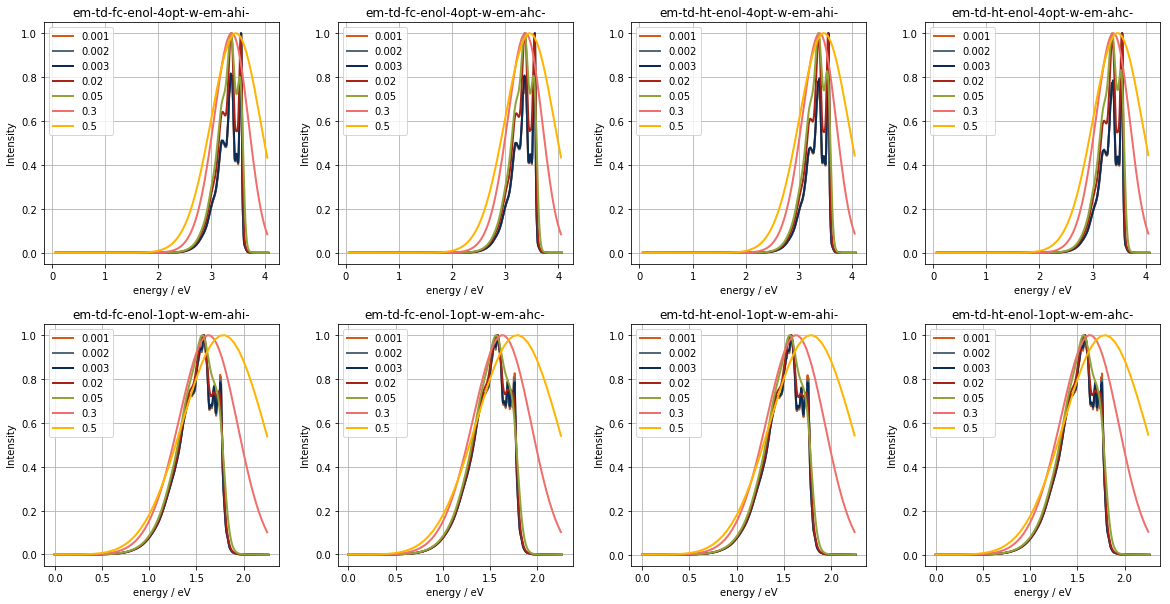

In [39]:
broadening = [0.001, 0.002, 0.003, 0.02, 0.05, 0.3, 0.5]
systems=['em-td-fc-enol-4opt-w-em-ahi-', 'em-td-fc-enol-4opt-w-em-ahc-', 'em-td-ht-enol-4opt-w-em-ahi-', 
         'em-td-ht-enol-4opt-w-em-ahc-', 'em-td-fc-enol-1opt-w-em-ahi-', 'em-td-fc-enol-1opt-w-em-ahc-', 
         'em-td-ht-enol-1opt-w-em-ahi-', 'em-td-ht-enol-1opt-w-em-ahc-']

plot_together(df_enol_td, broadening, systems, unit='ev', num_cols=4, num_rows=2)

### Parameters

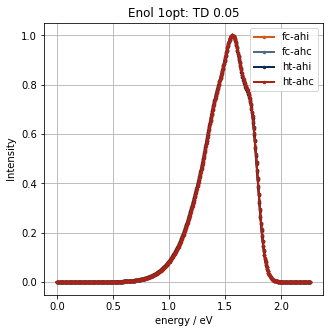

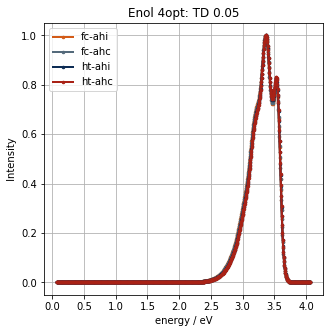

In [40]:
plt_enol4opt=['em-td-fc-enol-4opt-w-em-ahi-0.05', 'em-td-fc-enol-4opt-w-em-ahc-0.05', 'em-td-ht-enol-4opt-w-em-ahi-0.05', 
         'em-td-ht-enol-4opt-w-em-ahc-0.05']
plt_enol1opt=['em-td-fc-enol-1opt-w-em-ahi-0.05', 'em-td-fc-enol-1opt-w-em-ahc-0.05', 
         'em-td-ht-enol-1opt-w-em-ahi-0.05', 'em-td-ht-enol-1opt-w-em-ahc-0.05']

plot_sep(df_enol_td, plt_enol1opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Enol 1opt: TD 0.05')

plot_sep(df_enol_td, plt_enol4opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Enol 4opt: TD 0.05')

## Keto

In [129]:
df_keto_td = data_table(path_keto_td, unit='ev')
# df_keto_td.columns
# path_keto_td

### Broadening

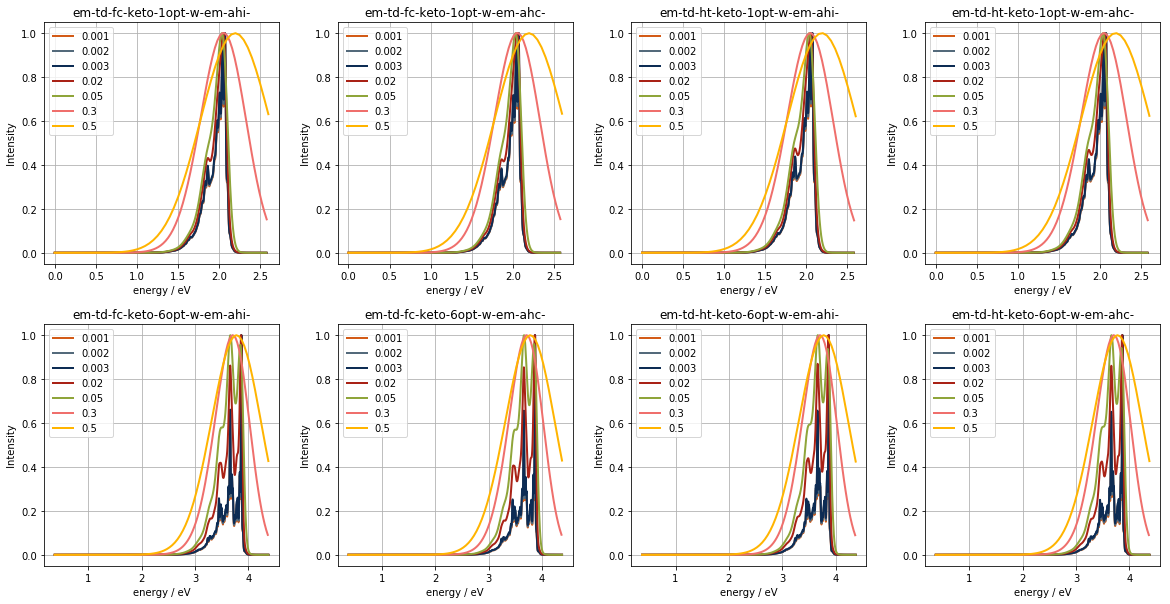

In [130]:
broadening = [0.001, 0.002, 0.003, 0.02, 0.05, 0.3, 0.5]
systems=['em-td-fc-keto-1opt-w-em-ahi-', 'em-td-fc-keto-1opt-w-em-ahc-', 'em-td-ht-keto-1opt-w-em-ahi-', 'em-td-ht-keto-1opt-w-em-ahc-',
       'em-td-fc-keto-6opt-w-em-ahi-', 'em-td-fc-keto-6opt-w-em-ahc-', 'em-td-ht-keto-6opt-w-em-ahi-', 'em-td-ht-keto-6opt-w-em-ahc-']
plot_together(df_keto_td, broadening, systems, unit='ev', num_cols=4, num_rows=2)

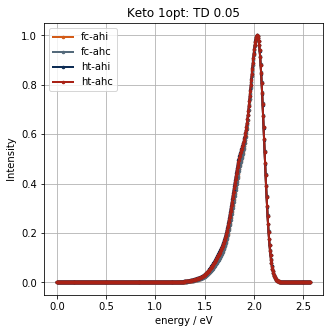

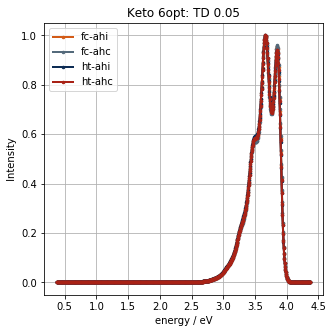

In [131]:
plt_keto6opt=['em-td-fc-keto-6opt-w-em-ahi-0.05', 'em-td-fc-keto-6opt-w-em-ahc-0.05', 'em-td-ht-keto-6opt-w-em-ahi-0.05', 
         'em-td-ht-keto-6opt-w-em-ahc-0.05']
plt_keto1opt=['em-td-fc-keto-1opt-w-em-ahi-0.05', 'em-td-fc-keto-1opt-w-em-ahc-0.05', 
         'em-td-ht-keto-1opt-w-em-ahi-0.05', 'em-td-ht-keto-1opt-w-em-ahc-0.05']

plot_sep(df_keto_td, plt_keto1opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Keto 1opt: TD 0.05')

plot_sep(df_keto_td, plt_keto6opt, unit='ev', type_plot='.', labels=['fc-ahi', 'fc-ahc', 'ht-ahi', 'ht-ahc'], name='Keto 6opt: TD 0.05')